## ME 449 Homework 9
Daniel Hufnagle

Import dependencies

In [768]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Load all signals as pandas dataframes

In [769]:
sigA_df = pd.read_csv('sigA.csv', header=None, dtype=float)
sigB_df = pd.read_csv('sigB.csv', header=None, dtype=float)
sigC_df = pd.read_csv('sigC.csv', header=None, dtype=float)
sigD_df = pd.read_csv('sigD.csv', header=None, dtype=float)

### Plot each signal with its FFT

Signal A

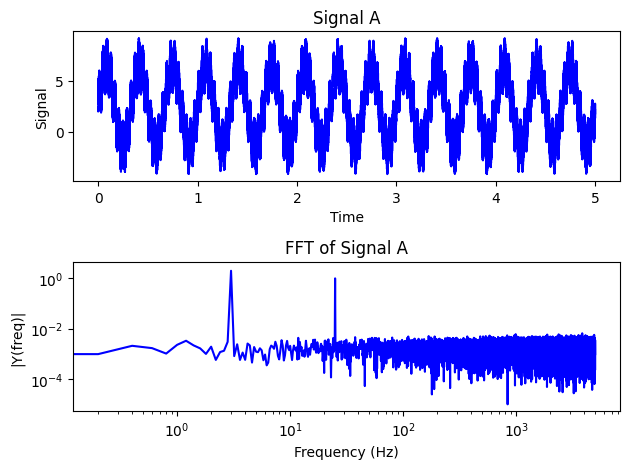

In [770]:
# get timestamps and signal
t_a = sigA_df[0].values
y_a = sigA_df[1].values

# make a 2x1 plot (1st is signal, 2nd is fft)
fig, (ax1, ax2) = plt.subplots(2, 1)

# plot signal
ax1.plot(t_a, y_a, 'b')
ax1.set_xlabel('Time')
ax1.set_ylabel('Signal')
ax1.set_title('Signal A')

# now perform FFT
Fs_a = len(t_a) / t_a[-1]
n_a = len(y_a)
k_a = np.arange(n_a)
T_a = n_a / Fs_a
frq_a = k_a / T_a
frq_a = frq_a[range(int(n_a/2))]
Y_a = np.fft.fft(y_a) / n_a
Y_a = Y_a[range(int(n_a/2))]

# plot FFT
ax2.loglog(frq_a, np.abs(Y_a), 'b')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax2.set_title('FFT of Signal A')

plt.tight_layout()
plt.show()

Signal B

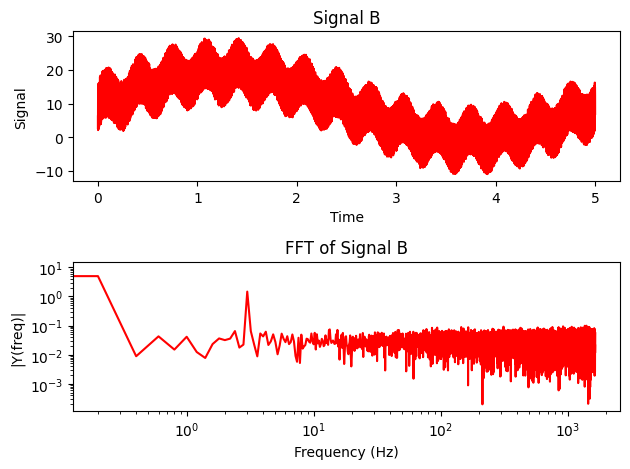

In [771]:
t_b = sigB_df[0].values
y_b = sigB_df[1].values

fig, (ax1, ax2) = plt.subplots(2, 1)

ax1.plot(t_b, y_b, 'r')
ax1.set_xlabel('Time')
ax1.set_ylabel('Signal')
ax1.set_title('Signal B')

Fs_b = len(t_b) / t_b[-1]
n_b = len(y_b)
k_b = np.arange(n_b)
T_b = n_b / Fs_b
frq_b = k_b / T_b
frq_b = frq_b[range(int(n_b/2))]
Y_b = np.fft.fft(y_b) / n_b
Y_b = Y_b[range(int(n_b/2))]

ax2.loglog(frq_b, np.abs(Y_b), 'r')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax2.set_title('FFT of Signal B')

plt.tight_layout()
plt.show()

Signal C

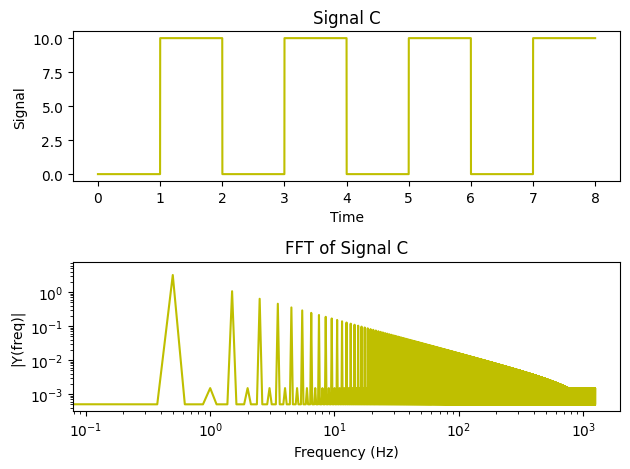

In [772]:
t_c = sigC_df[0].values
y_c = sigC_df[1].values

fig, (ax1, ax2) = plt.subplots(2, 1)

ax1.plot(t_c, y_c, 'y')
ax1.set_xlabel('Time')
ax1.set_ylabel('Signal')
ax1.set_title('Signal C')

Fs_c = len(t_c) / t_c[-1]
n_c = len(y_c)
k_c = np.arange(n_c)
T_c = n_c / Fs_c
frq_c = k_c / T_c
frq_c = frq_c[range(int(n_c/2))]
Y_c = np.fft.fft(y_c) / n_c
Y_c = Y_c[range(int(n_c/2))]

ax2.loglog(frq_c, np.abs(Y_c), 'y')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax2.set_title('FFT of Signal C')

plt.tight_layout()
plt.show()

Signal D

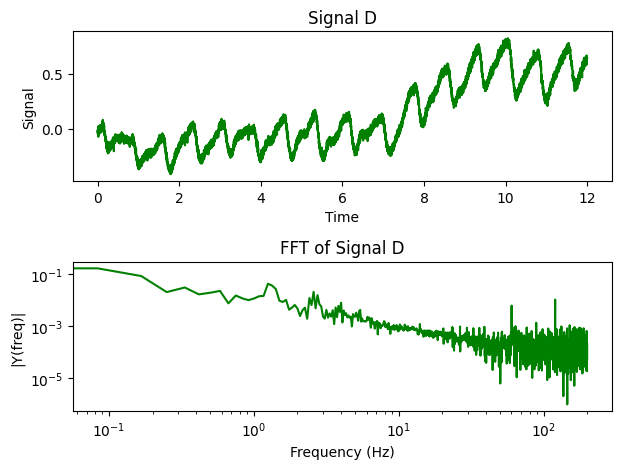

In [773]:
t_d = sigD_df[0].values
y_d = sigD_df[1].values

fig, (ax1, ax2) = plt.subplots(2, 1)

ax1.plot(t_d, y_d, 'g')
ax1.set_xlabel('Time')
ax1.set_ylabel('Signal')
ax1.set_title('Signal D')

Fs_d = len(t_d) / t_d[-1]
n_d = len(y_d)
k_d = np.arange(n_d)
T_d = n_d / Fs_d
frq_d = k_d / T_d
frq_d = frq_d[range(int(n_d/2))]
Y_d = np.fft.fft(y_d) / n_d
Y_d = Y_d[range(int(n_d/2))]

ax2.loglog(frq_d, np.abs(Y_d), 'g')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax2.set_title('FFT of Signal D')

plt.tight_layout()
plt.show()

### Low pass filtering with moving average filter

Signal A

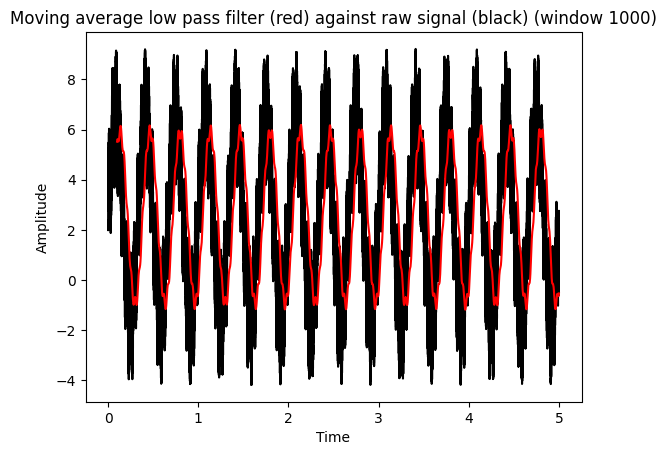

In [774]:
# moving average filter window
window_a = 1000

# calculate moving average and put it into dataframe
sigA_df[2] = sigA_df[1].rolling(window=window_a).mean()
maf_a = sigA_df[2].values

plt.plot(t_a, y_a, 'black')
plt.plot(t_a, maf_a, 'red')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title(f"Moving average low pass filter (red) against raw signal (black) (window {window_a})")
plt.show()

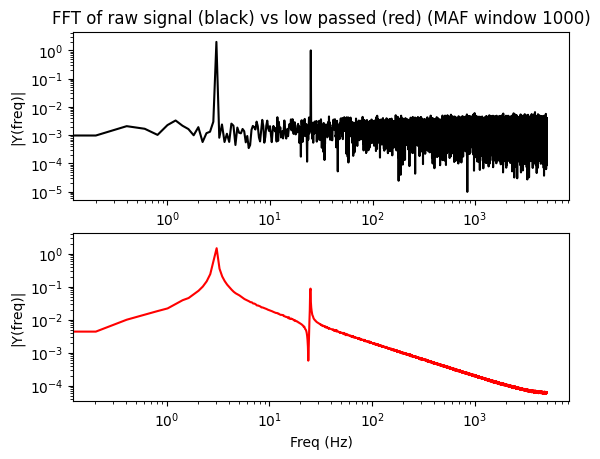

In [775]:
# perform FFT of low passed signal
# get the moving average filter values
t_maf_a = sigA_df.iloc[window_a:][0].values
y_maf_a = sigA_df.iloc[window_a:][2].values

Fs_maf_a = Fs_a
n_maf_a = len(y_maf_a)
k_maf_a = np.arange(n_maf_a)
T_maf_a = n_maf_a / Fs_maf_a
frq_maf_a = k_maf_a / T_maf_a
frq_maf_a = frq_maf_a[range(int(n_maf_a/2))]
Y_maf_a = np.fft.fft(y_maf_a)/n_maf_a
Y_maf_a = Y_maf_a[range(int(n_maf_a/2))]

# plot ffts
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.loglog(frq_a, np.abs(Y_a), 'black')
ax2.loglog(frq_maf_a, np.abs(Y_maf_a), 'red')
ax1.set_xlabel('Freq (Hz)')
ax1.set_ylabel('|Y(freq)|')
ax2.set_xlabel('Freq (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax1.set_title(f'FFT of raw signal (black) vs low passed (red) (MAF window {window_a})')
plt.show()

Signal B

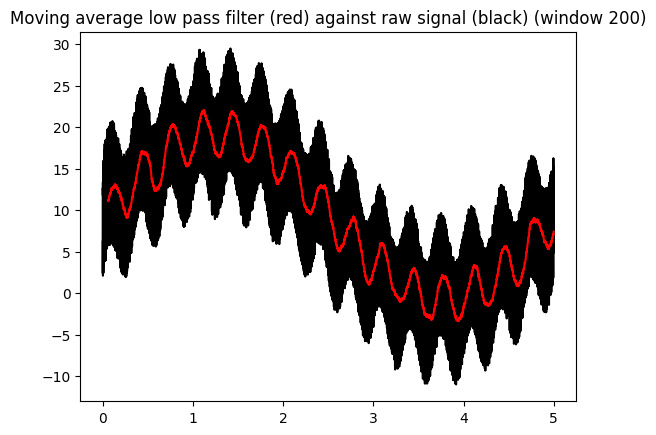

In [776]:
window_b = 200

sigB_df[2] = sigB_df[1].rolling(window=window_b).mean()
maf_b = sigB_df[2].values

plt.plot(t_b, y_b, 'black')
plt.plot(t_b, maf_b, 'red')
plt.title(f"Moving average low pass filter (red) against raw signal (black) (window {window_b})")
plt.show()

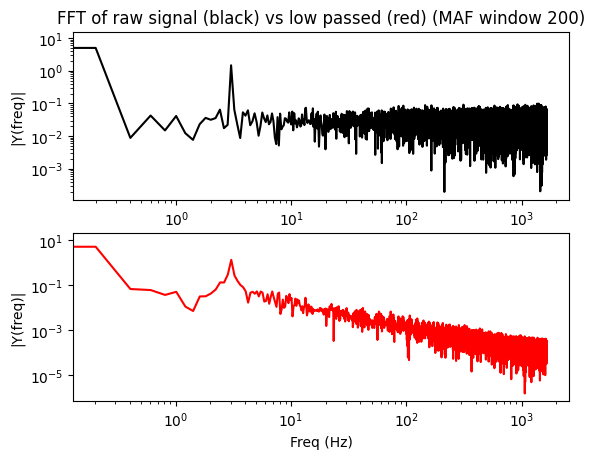

In [777]:
t_maf_b = sigB_df.iloc[window_b:][0].values
y_maf_b = sigB_df.iloc[window_b:][2].values

Fs_maf_b = Fs_b
n_maf_b = len(y_maf_b)
k_maf_b = np.arange(n_maf_b)
T_maf_b = n_maf_b / Fs_maf_b
frq_maf_b = k_maf_b / T_maf_b
frq_maf_b = frq_maf_b[range(int(n_maf_b/2))]
Y_maf_b = np.fft.fft(y_maf_b)/n_maf_b
Y_maf_b = Y_maf_b[range(int(n_maf_b/2))]

# plot ffts
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.loglog(frq_b, np.abs(Y_b), 'black')
ax2.loglog(frq_maf_b, np.abs(Y_maf_b), 'red')
ax1.set_xlabel('Freq (Hz)')
ax1.set_ylabel('|Y(freq)|')
ax2.set_xlabel('Freq (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax1.set_title(f'FFT of raw signal (black) vs low passed (red) (MAF window {window_b})')
plt.show()

Signal C

*Note: This signal is just a square wave without any noise (so there's nothing to filter out), so I'm just going to use this for the purpose of demonstrating heavy smoothing and delay from a large window*

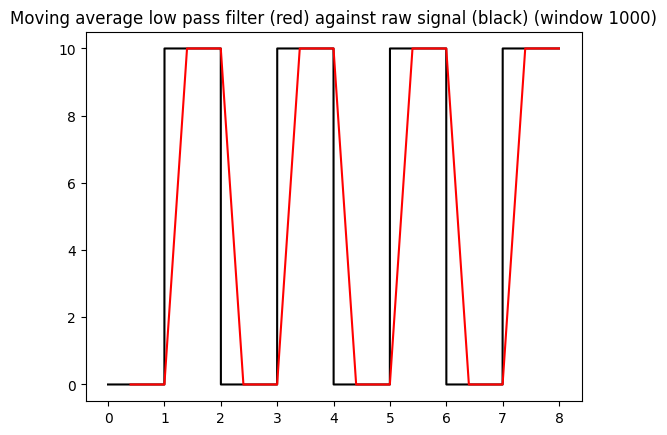

In [778]:
window_c = 1000

sigC_df[2] = sigC_df[1].rolling(window=window_c).mean()
maf_c = sigC_df[2].values

plt.plot(t_c, y_c, 'black')
plt.plot(t_c, maf_c, 'red')
plt.title(f"Moving average low pass filter (red) against raw signal (black) (window {window_c})")
plt.show()

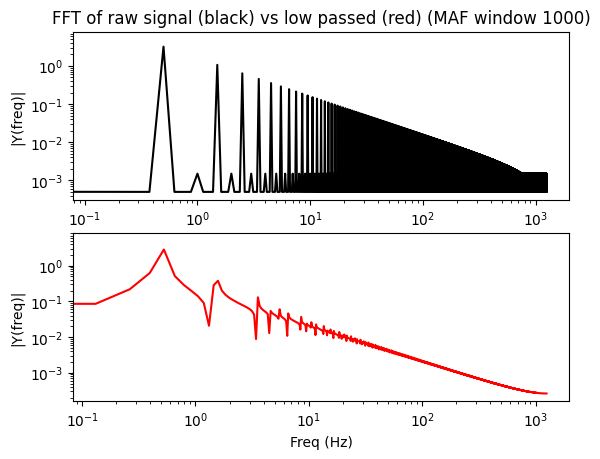

In [779]:
t_maf_c = sigC_df.iloc[window_c:][0].values
y_maf_c = sigC_df.iloc[window_c:][2].values

Fs_maf_c = Fs_c
n_maf_c = len(y_maf_c)
k_maf_c = np.arange(n_maf_c)
T_maf_c = n_maf_c / Fs_maf_c
frq_maf_c = k_maf_c / T_maf_c
frq_maf_c = frq_maf_c[range(int(n_maf_c/2))]
Y_maf_c = np.fft.fft(y_maf_c)/n_maf_c
Y_maf_c = Y_maf_c[range(int(n_maf_c/2))]

# plot ffts
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.loglog(frq_c, np.abs(Y_c), 'black')
ax2.loglog(frq_maf_c, np.abs(Y_maf_c), 'red')
ax1.set_xlabel('Freq (Hz)')
ax1.set_ylabel('|Y(freq)|')
ax2.set_xlabel('Freq (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax1.set_title(f'FFT of raw signal (black) vs low passed (red) (MAF window {window_c})')
plt.show()

Signal D

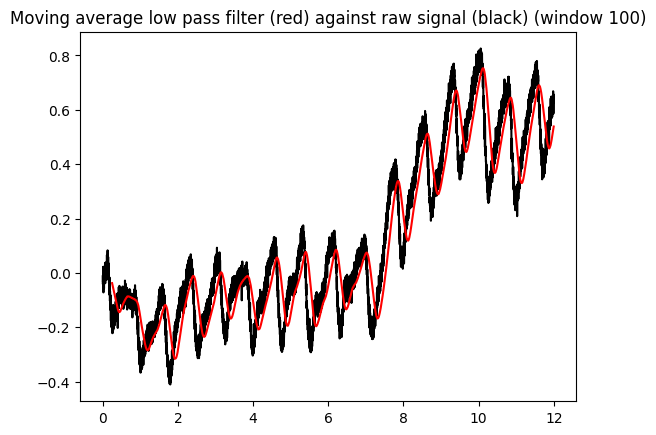

In [780]:
window_d = 100

sigD_df[2] = sigD_df[1].rolling(window=window_d).mean()
maf_d = sigD_df[2].values

plt.plot(t_d, y_d, 'black')
plt.plot(t_d, maf_d, 'red')
plt.title(f"Moving average low pass filter (red) against raw signal (black) (window {window_d})")
plt.show()

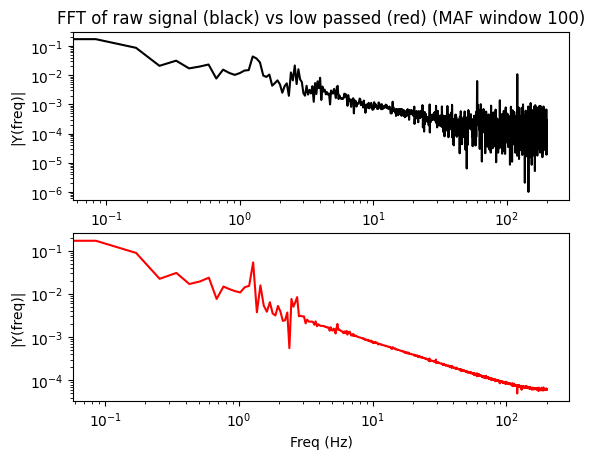

In [781]:
t_maf_d = sigD_df.iloc[window_d:][0].values
y_maf_d = sigD_df.iloc[window_d:][2].values

Fs_maf_d = Fs_d
n_maf_d = len(y_maf_d)
k_maf_d = np.arange(n_maf_d)
T_maf_d = n_maf_d / Fs_maf_d
frq_maf_d = k_maf_d / T_maf_d
frq_maf_d = frq_maf_d[range(int(n_maf_d/2))]
Y_maf_d = np.fft.fft(y_maf_d)/n_maf_d
Y_maf_d = Y_maf_d[range(int(n_maf_d/2))]

# plot ffts
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.loglog(frq_d, np.abs(Y_d), 'black')
ax2.loglog(frq_maf_d, np.abs(Y_maf_d), 'red')
ax1.set_xlabel('Freq (Hz)')
ax1.set_ylabel('|Y(freq)|')
ax2.set_xlabel('Freq (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax1.set_title(f'FFT of raw signal (black) vs low passed (red) (MAF window {window_d})')
plt.show()

### Low pass filtering with IIR

Signal A

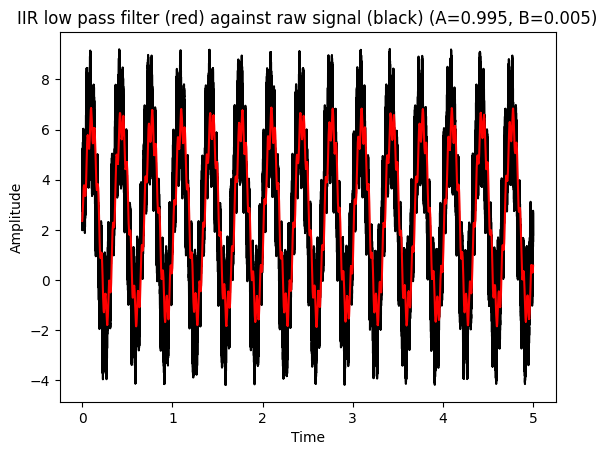

In [782]:
# IIR weights
A_a = 0.995 # weight for previous average
B_a = 0.005 # weight for current point

# calculate IIR and put it into dataframe
sigA_df[3] = 0.0
sigA_df.iloc[0, 3] = sigA_df.iloc[0, 1]
for i in range(1, len(sigA_df)):
    sigA_df.iloc[i, 3] = A_a * sigA_df.iloc[i-1, 3] + B_a * sigA_df.iloc[i, 1]

iir_a = sigA_df[3].values

plt.plot(t_a, y_a, 'black')
plt.plot(t_a, iir_a, 'red')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title(f"IIR low pass filter (red) against raw signal (black) (A={A_a}, B={B_a})")
plt.show()

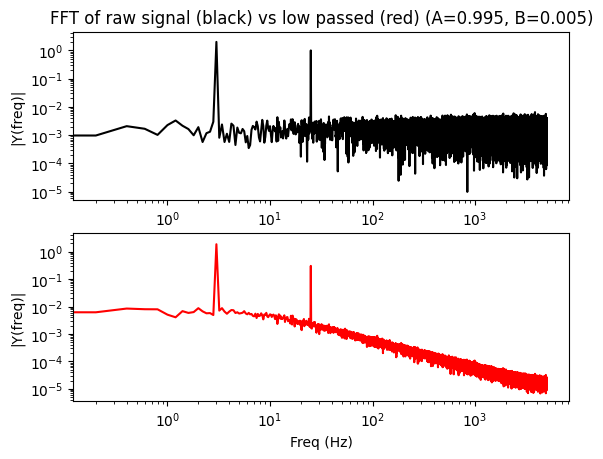

In [783]:
# perform FFT of low passed signal
# get the moving average filter values
y_iir_a = sigA_df[3].values

Fs_iir_a = Fs_a
n_iir_a = len(y_iir_a)
k_iir_a = np.arange(n_iir_a)
T_iir_a = n_iir_a / Fs_iir_a
frq_iir_a = k_iir_a / T_iir_a
frq_iir_a = frq_iir_a[range(int(n_iir_a/2))]
Y_iir_a = np.fft.fft(y_iir_a)/n_iir_a
Y_iir_a = Y_iir_a[range(int(n_iir_a/2))]

# plot ffts
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.loglog(frq_a, np.abs(Y_a), 'black')
ax2.loglog(frq_iir_a, np.abs(Y_iir_a), 'red')
ax1.set_xlabel('Freq (Hz)')
ax1.set_ylabel('|Y(freq)|')
ax2.set_xlabel('Freq (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax1.set_title(f'FFT of raw signal (black) vs low passed (red) (A={A_a}, B={B_a})')
plt.show()

Signal B

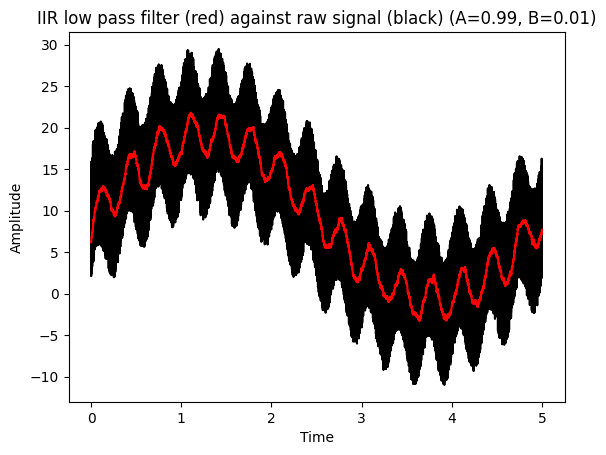

In [784]:
A_b = 0.99
B_b = 0.01

sigB_df[3] = 0.0
sigB_df.iloc[0, 3] = sigB_df.iloc[0, 1]
for i in range(1, len(sigB_df)):
    sigB_df.iloc[i, 3] = A_b * sigB_df.iloc[i-1, 3] + B_b * sigB_df.iloc[i, 1]

iir_b = sigB_df[3].values

plt.plot(t_b, y_b, 'black')
plt.plot(t_b, iir_b, 'red')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title(f"IIR low pass filter (red) against raw signal (black) (A={A_b}, B={B_b})")
plt.show()

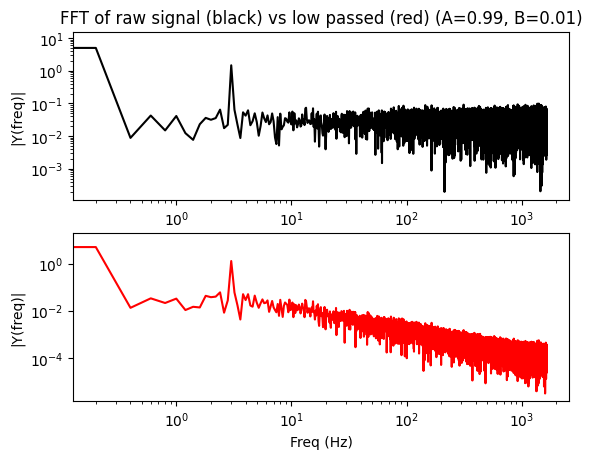

In [785]:
y_iir_b = sigB_df[3].values

Fs_iir_b = Fs_b
n_iir_b = len(y_iir_b)
k_iir_b = np.arange(n_iir_b)
T_iir_b = n_iir_b / Fs_iir_b
frq_iir_b = k_iir_b / T_iir_b
frq_iir_b = frq_iir_b[range(int(n_iir_b/2))]
Y_iir_b = np.fft.fft(y_iir_b)/n_iir_b
Y_iir_b = Y_iir_b[range(int(n_iir_b/2))]

# plot ffts
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.loglog(frq_b, np.abs(Y_b), 'black')
ax2.loglog(frq_iir_b, np.abs(Y_iir_b), 'red')
ax1.set_xlabel('Freq (Hz)')
ax1.set_ylabel('|Y(freq)|')
ax2.set_xlabel('Freq (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax1.set_title(f'FFT of raw signal (black) vs low passed (red) (A={A_b}, B={B_b})')
plt.show()

Signal C

*Note: I'm just going to do the same thing with this signal as I did with the MAF*

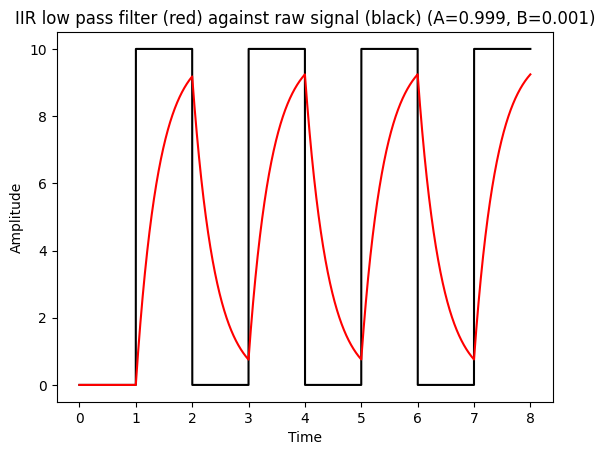

In [786]:
A_c = 0.999
B_c = 0.001

sigC_df[3] = 0.0
sigC_df.iloc[0, 3] = sigC_df.iloc[0, 1]
for i in range(1, len(sigC_df)):
    sigC_df.iloc[i, 3] = A_c * sigC_df.iloc[i-1, 3] + B_c * sigC_df.iloc[i, 1]

iir_c = sigC_df[3].values

plt.plot(t_c, y_c, 'black')
plt.plot(t_c, iir_c, 'red')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title(f"IIR low pass filter (red) against raw signal (black) (A={A_c}, B={B_c})")
plt.show()

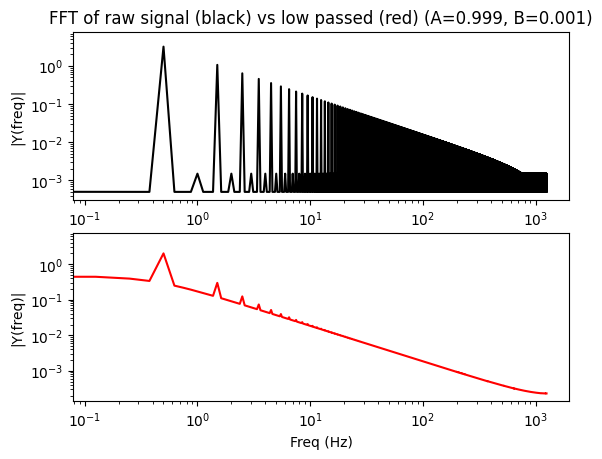

In [787]:
y_iir_c = sigC_df[3].values

Fs_iir_c = Fs_c
n_iir_c = len(y_iir_c)
k_iir_c = np.arange(n_iir_c)
T_iir_c = n_iir_c / Fs_iir_c
frq_iir_c = k_iir_c / T_iir_c
frq_iir_c = frq_iir_c[range(int(n_iir_c/2))]
Y_iir_c = np.fft.fft(y_iir_c)/n_iir_c
Y_iir_c = Y_iir_c[range(int(n_iir_c/2))]

# plot ffts
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.loglog(frq_c, np.abs(Y_c), 'black')
ax2.loglog(frq_iir_c, np.abs(Y_iir_c), 'red')
ax1.set_xlabel('Freq (Hz)')
ax1.set_ylabel('|Y(freq)|')
ax2.set_xlabel('Freq (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax1.set_title(f'FFT of raw signal (black) vs low passed (red) (A={A_c}, B={B_c})')
plt.show()

Signal D

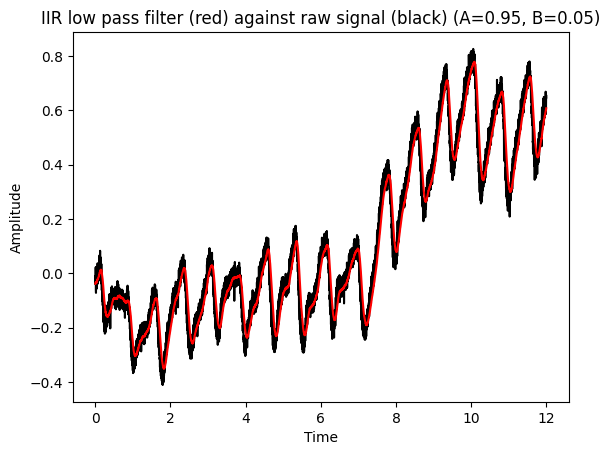

In [788]:
A_d = 0.95
B_d = 0.05

sigD_df[3] = 0.0
sigD_df.iloc[0, 3] = sigD_df.iloc[0, 1]
for i in range(1, len(sigD_df)):
    sigD_df.iloc[i, 3] = A_d * sigD_df.iloc[i-1, 3] + B_d * sigD_df.iloc[i, 1]

iir_d = sigD_df[3].values

plt.plot(t_d, y_d, 'black')
plt.plot(t_d, iir_d, 'red')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title(f"IIR low pass filter (red) against raw signal (black) (A={A_d}, B={B_d})")
plt.show()

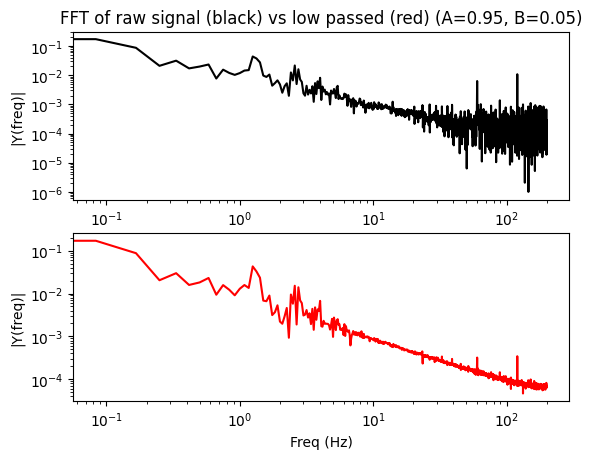

In [789]:
y_iir_d = sigD_df[3].values

Fs_iir_d = Fs_d
n_iir_d = len(y_iir_d)
k_iir_d = np.arange(n_iir_d)
T_iir_d = n_iir_d / Fs_iir_d
frq_iir_d = k_iir_d / T_iir_d
frq_iir_d = frq_iir_d[range(int(n_iir_d/2))]
Y_iir_d = np.fft.fft(y_iir_d)/n_iir_d
Y_iir_d = Y_iir_d[range(int(n_iir_d/2))]

fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.loglog(frq_d, np.abs(Y_d), 'black')
ax2.loglog(frq_iir_d, np.abs(Y_iir_d), 'red')
ax1.set_xlabel('Freq (Hz)')
ax1.set_ylabel('|Y(freq)|')
ax2.set_xlabel('Freq (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax1.set_title(f'FFT of raw signal (black) vs low passed (red) (A={A_d}, B={B_d})')
plt.show()

### Low pass filtering with FIR

Signal A

*100 Hz cutoff, 100 Hz bandwidth, Blackman window*

In [790]:
# FIR coefficients
h_a = [
    0.000000000000000000,
    0.000000022609304456,
    0.000000092137658127,
    0.000000210376981500,
    0.000000378074907886,
    0.000000594900325696,
    0.000000859416815111,
    0.000001169064300580,
    0.000001520149215920,
    0.000001907843452345,
    0.000002326192331196,
    0.000002768131812358,
    0.000003225515116128,
    0.000003689148900478,
    0.000004148839097111,
    0.000004593446468231,
    0.000005010951901591,
    0.000005388531413869,
    0.000005712640781930,
    0.000005969109667889,
    0.000006143245047260,
    0.000006219943689868,
    0.000006183813380806,
    0.000006019302503680,
    0.000005710837540961,
    0.000005242967976715,
    0.000004600518015692,
    0.000003768744460037,
    0.000002733500011260,
    0.000001481401190987,
    0.000000000000000000,
    -0.000001722041638279,
    -0.000003694775675826,
    -0.000005926791075647,
    -0.000008425037448593,
    -0.000011194650419114,
    -0.000014238780007746,
    -0.000017558423373286,
    -0.000021152263307200,
    -0.000025016513915877,
    -0.000029144774962341,
    -0.000033527896366957,
    -0.000038153854386003,
    -0.000043007640996822,
    -0.000048071168018069,
    -0.000053323187482591,
    -0.000058739229758206,
    -0.000064291560877524,
    -0.000069949160491469,
    -0.000075677721802043,
    -0.000081439674757675,
    -0.000087194233709117,
    -0.000092897470625088,
    -0.000098502414854722,
    -0.000103959180298482,
    -0.000109215120710603,
    -0.000114215013704846,
    -0.000118901273871578,
    -0.000123214195238642,
    -0.000127092223121715,
    -0.000130472255212696,
    -0.000133289971547970,
    -0.000135480192783221,
    -0.000136977265978890,
    -0.000137715476871664,
    -0.000137629487373880,
    -0.000136654796805819,
    -0.000134728225127145,
    -0.000131788416194798,
    -0.000127776358837126,
    -0.000122635923299772,
    -0.000116314410389517,
    -0.000108763110419883,
    -0.000099937868848572,
    -0.000089799655293773,
    -0.000078315132425799,
    -0.000065457221054363,
    -0.000051205657571931,
    -0.000035547539771790,
    -0.000018477856937501,
    0.000000000000000000,
    0.000019873752518615,
    0.000041121777108205,
    0.000063712680780720,
    0.000087604913846630,
    0.000112746424287725,
    0.000139074357997619,
    0.000166514809072417,
    0.000194982624214208,
    0.000224381265158973,
    0.000254602732857888,
    0.000285527556926846,
    0.000317024853633430,
    0.000348952455414073,
    0.000381157114607204,
    0.000413474783751794,
    0.000445730974435899,
    0.000477741196287834,
    0.000509311477285098,
    0.000540238966114795,
    0.000570312616856111,
    0.000599313955772492,
    0.000627017929501001,
    0.000653193833411438,
    0.000677606318380946,
    0.000700016473693936,
    0.000720182983235291,
    0.000737863351600188,
    0.000752815196199786,
    0.000764797600901996,
    0.000773572526213876,
    0.000778906270490711,
    0.000780570976149873,
    0.000778346174378884,
    0.000772020361360302,
    0.000761392598594556,
    0.000746274129489374,
    0.000726490004004188,
    0.000701880702793345,
    0.000672303751986135,
    0.000637635319477743,
    0.000597771783385927,
    0.000552631263156265,
    0.000502155103676596,
    0.000446309302690953,
    0.000385085871786737,
    0.000318504121267832,
    0.000246611859321968,
    0.000169486496044106,
    0.000087236043089405,
    0.000000000000000000,
    -0.000092049881420886,
    -0.000188708962926191,
    -0.000289739223627016,
    -0.000394868909070879,
    -0.000503792332330792,
    -0.000616169833229712,
    -0.000731627901163730,
    -0.000849759466277988,
    -0.000970124362994252,
    -0.001092249969091942,
    -0.001215632022708469,
    -0.001339735618754229,
    -0.001463996385336302,
    -0.001587821839857698,
    -0.001710592923510197,
    -0.001831665711913682,
    -0.001950373298678269,
    -0.002066027847682981,
    -0.002177922808881408,
    -0.002285335291466635,
    -0.002387528587259935,
    -0.002483754836236344,
    -0.002573257825170752,
    -0.002655275909486315,
    -0.002729045047518393,
    -0.002793801935577453,
    -0.002848787231408712,
    -0.002893248852910153,
    -0.002926445338288832,
    -0.002947649253212949,
    -0.002956150629958684,
    -0.002951260423060331,
    -0.002932313965553967,
    -0.002898674409562282,
    -0.002849736134704403,
    -0.002784928107632618,
    -0.002703717175899989,
    -0.002605611279351113,
    -0.002490162562303985,
    -0.002356970369955443,
    -0.002205684112696052,
    -0.002036005982363005,
    -0.001847693504890926,
    -0.001640561914339420,
    -0.001414486333881437,
    -0.001169403750025814,
    -0.000905314767118358,
    -0.000622285130015536,
    -0.000320447003749589,
    0.000000000000000001,
    0.000338788058750984,
    0.000695580645376159,
    0.001069972311390398,
    0.001461488752950066,
    0.001869587163870110,
    0.002293656878647479,
    0.002733020307130437,
    0.003186934161098913,
    0.003654590971628138,
    0.004135120894703703,
    0.004627593801148187,
    0.005131021645515233,
    0.005644361107213516,
    0.006166516495748513,
    0.006696342910621199,
    0.007232649645107787,
    0.007774203821870057,
    0.008319734247119286,
    0.008867935468884999,
    0.009417472023829232,
    0.009966982856004428,
    0.010515085889984224,
    0.011060382739907122,
    0.011601463535168466,
    0.012136911842781345,
    0.012665309665806286,
    0.013185242496726660,
    0.013695304404225379,
    0.014194103131501134,
    0.014680265184051732,
    0.015152440884749678,
    0.015609309374042002,
    0.016049583533223350,
    0.016472014808958144,
    0.016875397917563813,
    0.017258575408011220,
    0.017620442063148847,
    0.017959949119311452,
    0.018276108285228888,
    0.018567995542002971,
    0.018834754706865513,
    0.019075600744464558,
    0.019289822810542985,
    0.019476787014068648,
    0.019635938885141990,
    0.019766805537339234,
    0.019868997514539938,
    0.019942210313729766,
    0.019986225576755702,
    0.020000911945533145,
    0.019986225576755702,
    0.019942210313729766,
    0.019868997514539938,
    0.019766805537339234,
    0.019635938885141990,
    0.019476787014068648,
    0.019289822810542985,
    0.019075600744464561,
    0.018834754706865513,
    0.018567995542002971,
    0.018276108285228892,
    0.017959949119311456,
    0.017620442063148851,
    0.017258575408011220,
    0.016875397917563817,
    0.016472014808958144,
    0.016049583533223350,
    0.015609309374042002,
    0.015152440884749678,
    0.014680265184051732,
    0.014194103131501134,
    0.013695304404225379,
    0.013185242496726660,
    0.012665309665806286,
    0.012136911842781345,
    0.011601463535168468,
    0.011060382739907124,
    0.010515085889984224,
    0.009966982856004430,
    0.009417472023829233,
    0.008867935468885001,
    0.008319734247119286,
    0.007774203821870058,
    0.007232649645107790,
    0.006696342910621201,
    0.006166516495748514,
    0.005644361107213516,
    0.005131021645515233,
    0.004627593801148190,
    0.004135120894703703,
    0.003654590971628138,
    0.003186934161098913,
    0.002733020307130436,
    0.002293656878647479,
    0.001869587163870110,
    0.001461488752950066,
    0.001069972311390398,
    0.000695580645376159,
    0.000338788058750984,
    0.000000000000000001,
    -0.000320447003749589,
    -0.000622285130015536,
    -0.000905314767118358,
    -0.001169403750025814,
    -0.001414486333881437,
    -0.001640561914339420,
    -0.001847693504890926,
    -0.002036005982363005,
    -0.002205684112696052,
    -0.002356970369955444,
    -0.002490162562303986,
    -0.002605611279351114,
    -0.002703717175899990,
    -0.002784928107632618,
    -0.002849736134704405,
    -0.002898674409562284,
    -0.002932313965553968,
    -0.002951260423060331,
    -0.002956150629958684,
    -0.002947649253212949,
    -0.002926445338288832,
    -0.002893248852910154,
    -0.002848787231408712,
    -0.002793801935577453,
    -0.002729045047518393,
    -0.002655275909486314,
    -0.002573257825170751,
    -0.002483754836236344,
    -0.002387528587259935,
    -0.002285335291466637,
    -0.002177922808881409,
    -0.002066027847682983,
    -0.001950373298678270,
    -0.001831665711913683,
    -0.001710592923510196,
    -0.001587821839857699,
    -0.001463996385336302,
    -0.001339735618754230,
    -0.001215632022708470,
    -0.001092249969091943,
    -0.000970124362994253,
    -0.000849759466277988,
    -0.000731627901163730,
    -0.000616169833229712,
    -0.000503792332330792,
    -0.000394868909070879,
    -0.000289739223627016,
    -0.000188708962926191,
    -0.000092049881420886,
    0.000000000000000000,
    0.000087236043089405,
    0.000169486496044106,
    0.000246611859321969,
    0.000318504121267832,
    0.000385085871786737,
    0.000446309302690953,
    0.000502155103676596,
    0.000552631263156265,
    0.000597771783385928,
    0.000637635319477744,
    0.000672303751986135,
    0.000701880702793346,
    0.000726490004004188,
    0.000746274129489374,
    0.000761392598594557,
    0.000772020361360302,
    0.000778346174378885,
    0.000780570976149873,
    0.000778906270490711,
    0.000773572526213877,
    0.000764797600901996,
    0.000752815196199787,
    0.000737863351600188,
    0.000720182983235291,
    0.000700016473693937,
    0.000677606318380946,
    0.000653193833411439,
    0.000627017929501001,
    0.000599313955772492,
    0.000570312616856111,
    0.000540238966114796,
    0.000509311477285099,
    0.000477741196287834,
    0.000445730974435899,
    0.000413474783751794,
    0.000381157114607204,
    0.000348952455414074,
    0.000317024853633430,
    0.000285527556926846,
    0.000254602732857889,
    0.000224381265158973,
    0.000194982624214209,
    0.000166514809072417,
    0.000139074357997619,
    0.000112746424287725,
    0.000087604913846630,
    0.000063712680780720,
    0.000041121777108205,
    0.000019873752518615,
    0.000000000000000000,
    -0.000018477856937501,
    -0.000035547539771790,
    -0.000051205657571931,
    -0.000065457221054363,
    -0.000078315132425799,
    -0.000089799655293773,
    -0.000099937868848572,
    -0.000108763110419883,
    -0.000116314410389517,
    -0.000122635923299772,
    -0.000127776358837126,
    -0.000131788416194798,
    -0.000134728225127145,
    -0.000136654796805820,
    -0.000137629487373880,
    -0.000137715476871664,
    -0.000136977265978890,
    -0.000135480192783221,
    -0.000133289971547970,
    -0.000130472255212695,
    -0.000127092223121715,
    -0.000123214195238642,
    -0.000118901273871578,
    -0.000114215013704845,
    -0.000109215120710603,
    -0.000103959180298482,
    -0.000098502414854722,
    -0.000092897470625088,
    -0.000087194233709117,
    -0.000081439674757675,
    -0.000075677721802043,
    -0.000069949160491469,
    -0.000064291560877524,
    -0.000058739229758206,
    -0.000053323187482591,
    -0.000048071168018069,
    -0.000043007640996822,
    -0.000038153854386003,
    -0.000033527896366957,
    -0.000029144774962341,
    -0.000025016513915877,
    -0.000021152263307200,
    -0.000017558423373287,
    -0.000014238780007746,
    -0.000011194650419114,
    -0.000008425037448593,
    -0.000005926791075647,
    -0.000003694775675826,
    -0.000001722041638279,
    0.000000000000000000,
    0.000001481401190987,
    0.000002733500011260,
    0.000003768744460037,
    0.000004600518015692,
    0.000005242967976715,
    0.000005710837540961,
    0.000006019302503680,
    0.000006183813380806,
    0.000006219943689868,
    0.000006143245047260,
    0.000005969109667889,
    0.000005712640781930,
    0.000005388531413869,
    0.000005010951901591,
    0.000004593446468231,
    0.000004148839097111,
    0.000003689148900478,
    0.000003225515116128,
    0.000002768131812358,
    0.000002326192331196,
    0.000001907843452345,
    0.000001520149215920,
    0.000001169064300580,
    0.000000859416815111,
    0.000000594900325696,
    0.000000378074907886,
    0.000000210376981500,
    0.000000092137658127,
    0.000000022609304456,
    0.000000000000000000,
]


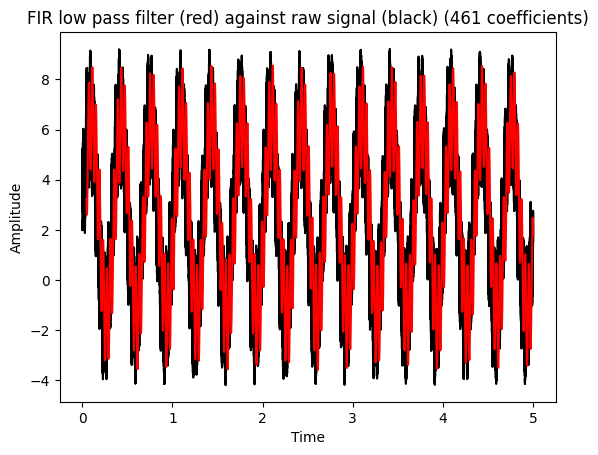

In [791]:
# calculate moving average and put it into dataframe
sigA_df[4] = sigA_df[1].rolling(window=len(h_a)).apply(lambda x: np.sum(h_a * x), raw=True)
fir_a = sigA_df[4].values

plt.plot(t_a, y_a, 'black')
plt.plot(t_a, fir_a, 'red')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title(f"FIR low pass filter (red) against raw signal (black) ({len(h_a)} coefficients)")
plt.show()

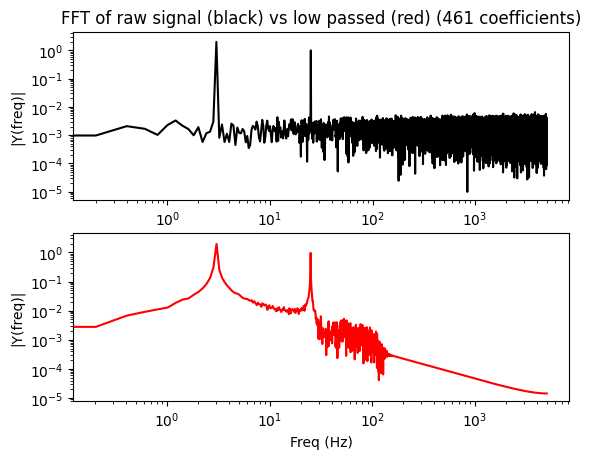

In [792]:
# perform FFT of low passed signal
# get the moving average filter values
t_fir_a = sigA_df.iloc[len(h_a):][0].values
y_fir_a = sigA_df.iloc[len(h_a):][4].values

Fs_fir_a = Fs_a
n_fir_a = len(y_fir_a)
k_fir_a = np.arange(n_fir_a)
T_fir_a = n_fir_a / Fs_fir_a
frq_fir_a = k_fir_a / T_fir_a
frq_fir_a = frq_fir_a[range(int(n_fir_a/2))]
Y_fir_a = np.fft.fft(y_fir_a)/n_fir_a
Y_fir_a = Y_fir_a[range(int(n_fir_a/2))]

# plot ffts
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.loglog(frq_a, np.abs(Y_a), 'black')
ax2.loglog(frq_fir_a, np.abs(Y_fir_a), 'red')
ax1.set_xlabel('Freq (Hz)')
ax1.set_ylabel('|Y(freq)|')
ax2.set_xlabel('Freq (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax1.set_title(f'FFT of raw signal (black) vs low passed (red) ({len(h_a)} coefficients)')
plt.show()

Signal B

*2 Hz cutoff frequency, 2 Hz bandwidth, Blackman window*

In [793]:
h_b = [
    0.000000000000000000,
    0.000000184275316228,
    0.000000756149815669,
    0.000001718833629986,
    0.000003040298431423,
    0.000004652384661754,
    0.000006451030231371,
    0.000008297678193084,
    0.000010021903801808,
    0.000011425281562294,
    0.000012286490092836,
    0.000012367626759916,
    0.000011421675080358,
    0.000009201036030123,
    0.000005467000021771,
    0.000000000000000000,
    -0.000007389551350640,
    -0.000016850074894876,
    -0.000028477560011589,
    -0.000042304526608602,
    -0.000058289549916693,
    -0.000076307708761548,
    -0.000096142336022962,
    -0.000117478459500312,
    -0.000139898320963765,
    -0.000162879349493027,
    -0.000185794941224712,
    -0.000207918360568469,
    -0.000228430027378385,
    -0.000246428390443510,
    -0.000260944510389629,
    -0.000270960385529308,
    -0.000275430953705580,
    -0.000273309593574182,
    -0.000263576832353472,
    -0.000245271846565929,
    -0.000217526220809955,
    -0.000179599310562932,
    -0.000130914442090783,
    -0.000071095079533837,
    0.000000000000000000,
    0.000082243554205139,
    0.000175209827669248,
    0.000278148715957118,
    0.000389965248374972,
    0.000509205465645991,
    0.000634049707179963,
    0.000762314229109934,
    0.000891461948749623,
    0.001018622954430595,
    0.001140625233555900,
    0.001254035858830138,
    0.001355212636576161,
    0.001440365966273182,
    0.001505630392193227,
    0.001547145052215717,
    0.001561141952085793,
    0.001544040722508995,
    0.001492548258774194,
    0.001403761405394306,
    0.001275270638780711,
    0.001105262526161054,
    0.000892618605259573,
    0.000637008242448363,
    0.000338972992041757,
    -0.000000000000000001,
    -0.000377417925800657,
    -0.000789737818033524,
    -0.001232339666290532,
    -0.001699518932323058,
    -0.002184499937884500,
    -0.002679471237141239,
    -0.003175643679280177,
    -0.003663331423325306,
    -0.004132055694799667,
    -0.004570670582306863,
    -0.004967509671791893,
    -0.005310551818244822,
    -0.005587603870389130,
    -0.005786497705027271,
    -0.005895298505617951,
    -0.005902520845311724,
    -0.005797348818330043,
    -0.005569856214501891,
    -0.005211222557988031,
    -0.004713940739264844,
    -0.004072011964167944,
    -0.003281123828229164,
    -0.002338807499731096,
    -0.001244570259860504,
    0.000000000000000001,
    0.001391161290561661,
    0.002922977505499540,
    0.004587313756666270,
    0.006373868321324293,
    0.008270241788273975,
    0.010262043289624059,
    0.012333032989806791,
    0.014465299288233115,
    0.016639468491958145,
    0.018834944045077146,
    0.021030171777086274,
    0.023202927067156986,
    0.025330619328141027,
    0.027390608804696893,
    0.029360530364079623,
    0.031218618743805514,
    0.032944029613401329,
    0.034517150811291884,
    0.035919898233700107,
    0.037135991078916478,
    0.038151201483700520,
    0.038953574022798733,
    0.039533611069260413,
    0.039884420621993398,
    0.040001823885584063,
    0.039884420621993398,
    0.039533611069260413,
    0.038953574022798733,
    0.038151201483700520,
    0.037135991078916478,
    0.035919898233700114,
    0.034517150811291891,
    0.032944029613401329,
    0.031218618743805514,
    0.029360530364079623,
    0.027390608804696893,
    0.025330619328141027,
    0.023202927067156990,
    0.021030171777086274,
    0.018834944045077150,
    0.016639468491958145,
    0.014465299288233121,
    0.012333032989806793,
    0.010262043289624059,
    0.008270241788273975,
    0.006373868321324291,
    0.004587313756666270,
    0.002922977505499540,
    0.001391161290561661,
    0.000000000000000001,
    -0.001244570259860504,
    -0.002338807499731096,
    -0.003281123828229164,
    -0.004072011964167944,
    -0.004713940739264845,
    -0.005211222557988032,
    -0.005569856214501891,
    -0.005797348818330045,
    -0.005902520845311724,
    -0.005895298505617951,
    -0.005786497705027272,
    -0.005587603870389130,
    -0.005310551818244821,
    -0.004967509671791893,
    -0.004570670582306867,
    -0.004132055694799671,
    -0.003663331423325309,
    -0.003175643679280179,
    -0.002679471237141239,
    -0.002184499937884501,
    -0.001699518932323058,
    -0.001232339666290532,
    -0.000789737818033524,
    -0.000377417925800658,
    -0.000000000000000001,
    0.000338972992041757,
    0.000637008242448363,
    0.000892618605259573,
    0.001105262526161055,
    0.001275270638780712,
    0.001403761405394307,
    0.001492548258774195,
    0.001544040722508995,
    0.001561141952085793,
    0.001547145052215719,
    0.001505630392193229,
    0.001440365966273182,
    0.001355212636576161,
    0.001254035858830137,
    0.001140625233555901,
    0.001018622954430595,
    0.000891461948749624,
    0.000762314229109934,
    0.000634049707179964,
    0.000509205465645991,
    0.000389965248374973,
    0.000278148715957118,
    0.000175209827669248,
    0.000082243554205139,
    0.000000000000000000,
    -0.000071095079533837,
    -0.000130914442090784,
    -0.000179599310562932,
    -0.000217526220809955,
    -0.000245271846565929,
    -0.000263576832353473,
    -0.000273309593574182,
    -0.000275430953705580,
    -0.000270960385529308,
    -0.000260944510389629,
    -0.000246428390443510,
    -0.000228430027378385,
    -0.000207918360568470,
    -0.000185794941224712,
    -0.000162879349493027,
    -0.000139898320963765,
    -0.000117478459500312,
    -0.000096142336022963,
    -0.000076307708761548,
    -0.000058289549916693,
    -0.000042304526608602,
    -0.000028477560011589,
    -0.000016850074894876,
    -0.000007389551350640,
    0.000000000000000000,
    0.000005467000021771,
    0.000009201036030123,
    0.000011421675080358,
    0.000012367626759916,
    0.000012286490092836,
    0.000011425281562294,
    0.000010021903801808,
    0.000008297678193084,
    0.000006451030231371,
    0.000004652384661754,
    0.000003040298431423,
    0.000001718833629986,
    0.000000756149815669,
    0.000000184275316228,
    0.000000000000000000,
]

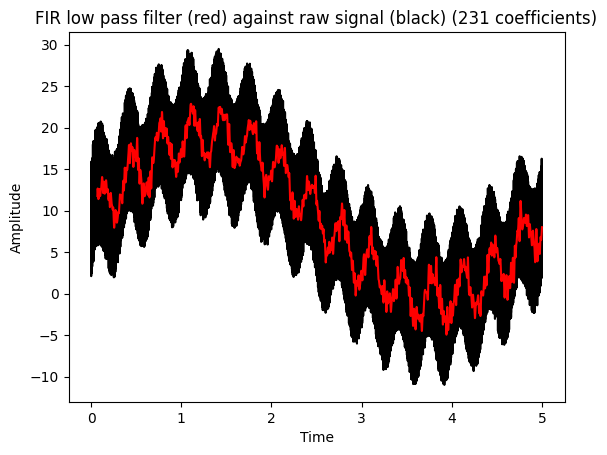

In [794]:
sigB_df[4] = sigB_df[1].rolling(window=len(h_b)).apply(lambda x: np.sum(h_b * x), raw=True)
fir_b = sigB_df[4].values

plt.plot(t_b, y_b, 'black')
plt.plot(t_b, fir_b, 'red')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title(f"FIR low pass filter (red) against raw signal (black) ({len(h_b)} coefficients)")
plt.show()

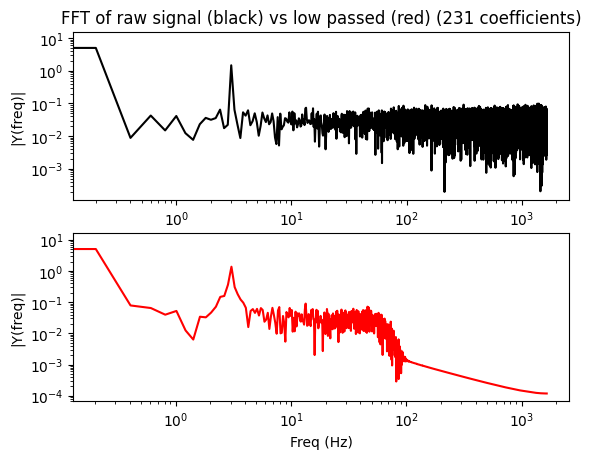

In [795]:
t_fir_b = sigB_df.iloc[len(h_b):][0].values
y_fir_b = sigB_df.iloc[len(h_b):][4].values

Fs_fir_b = Fs_b
n_fir_b = len(y_fir_b)
k_fir_b = np.arange(n_fir_b)
T_fir_b = n_fir_b / Fs_fir_b
frq_fir_b = k_fir_b / T_fir_b
frq_fir_b = frq_fir_b[range(int(n_fir_b/2))]
Y_fir_b = np.fft.fft(y_fir_b)/n_fir_b
Y_fir_b = Y_fir_b[range(int(n_fir_b/2))]

fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.loglog(frq_b, np.abs(Y_b), 'black')
ax2.loglog(frq_fir_b, np.abs(Y_fir_b), 'red')
ax1.set_xlabel('Freq (Hz)')
ax1.set_ylabel('|Y(freq)|')
ax2.set_xlabel('Freq (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax1.set_title(f'FFT of raw signal (black) vs low passed (red) ({len(h_b)} coefficients)')
plt.show()

Signal C

*Same deal here, applying an aggressive filter to see what happens*
*1 Hz cutoff frequency, 0.5 Hz bandwidth, Blackman window*

In [796]:
h_c = [
    0.000000000000000000,
    -0.000000181721163200,
    0.000000739385827034,
    0.000004792182838984,
    0.000012811062543596,
    0.000023499373749790,
    0.000033133009089505,
    0.000036134967769683,
    0.000026526673733780,
    0.000000000000000000,
    -0.000043883706648787,
    -0.000100009892140500,
    -0.000157189577545754,
    -0.000199279666885285,
    -0.000208090023048963,
    -0.000167773664521323,
    -0.000069922275658454,
    0.000081794760082463,
    0.000268785557414477,
    0.000457699451139842,
    0.000604354157089433,
    0.000661425212592421,
    0.000588965035072406,
    0.000365902523759915,
    -0.000000000000000001,
    -0.000466471852157123,
    -0.000957689137437149,
    -0.001373175674598225,
    -0.001604404206218450,
    -0.001557022130410154,
    -0.001174899555252437,
    -0.000460994149251607,
    0.000510276928116078,
    0.001593634771775522,
    0.002588991370982918,
    0.003272528879620183,
    0.003439025575818268,
    0.002948520809938009,
    0.001768228438276014,
    -0.000000000000000002,
    -0.002115008509519164,
    -0.004219475833459812,
    -0.005890946539740757,
    -0.006715119751948016,
    -0.006370314117701113,
    -0.004708013356513700,
    -0.001812834710739202,
    0.001973197273417098,
    0.006072444645764933,
    0.009742471389667809,
    0.012189865578668101,
    0.012712095983581332,
    0.010845211887175828,
    0.006491286661400424,
    -0.000000000000000004,
    -0.007815994094067214,
    -0.015742770550057076,
    -0.022302382069478401,
    -0.025950866010718020,
    -0.025310406509330297,
    -0.019400909896389023,
    -0.007833498737268485,
    0.009068094287572820,
    0.030242776550885683,
    0.053974374122717751,
    0.078074689336089756,
    0.100144721614431748,
    0.117878137245723894,
    0.129363198241395055,
    0.133338385948291061,
    0.129363198241395055,
    0.117878137245723894,
    0.100144721614431748,
    0.078074689336089770,
    0.053974374122717751,
    0.030242776550885683,
    0.009068094287572822,
    -0.007833498737268487,
    -0.019400909896389030,
    -0.025310406509330304,
    -0.025950866010718020,
    -0.022302382069478412,
    -0.015742770550057083,
    -0.007815994094067214,
    -0.000000000000000004,
    0.006491286661400425,
    0.010845211887175830,
    0.012712095983581341,
    0.012189865578668108,
    0.009742471389667809,
    0.006072444645764933,
    0.001973197273417099,
    -0.001812834710739203,
    -0.004708013356513704,
    -0.006370314117701116,
    -0.006715119751948020,
    -0.005890946539740759,
    -0.004219475833459814,
    -0.002115008509519166,
    -0.000000000000000002,
    0.001768228438276015,
    0.002948520809938010,
    0.003439025575818270,
    0.003272528879620186,
    0.002588991370982917,
    0.001593634771775522,
    0.000510276928116078,
    -0.000460994149251607,
    -0.001174899555252438,
    -0.001557022130410156,
    -0.001604404206218450,
    -0.001373175674598226,
    -0.000957689137437150,
    -0.000466471852157124,
    -0.000000000000000001,
    0.000365902523759915,
    0.000588965035072407,
    0.000661425212592421,
    0.000604354157089434,
    0.000457699451139843,
    0.000268785557414478,
    0.000081794760082463,
    -0.000069922275658454,
    -0.000167773664521323,
    -0.000208090023048963,
    -0.000199279666885286,
    -0.000157189577545754,
    -0.000100009892140500,
    -0.000043883706648787,
    0.000000000000000000,
    0.000026526673733780,
    0.000036134967769683,
    0.000033133009089506,
    0.000023499373749791,
    0.000012811062543596,
    0.000004792182838984,
    0.000000739385827034,
    -0.000000181721163200,
    0.000000000000000000,
]

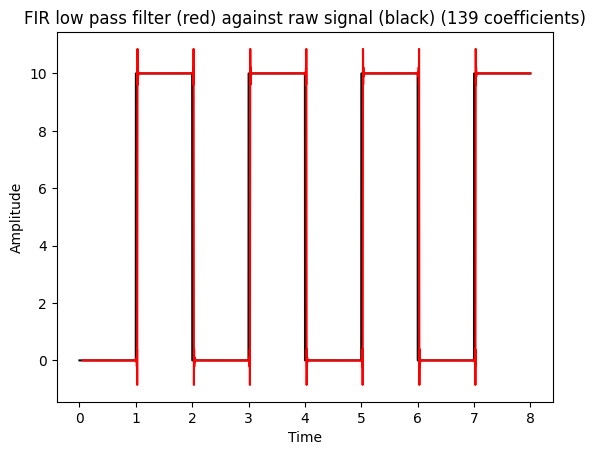

In [797]:
sigC_df[4] = sigC_df[1].rolling(window=len(h_c)).apply(lambda x: np.sum(h_c * x), raw=True)
fir_c = sigC_df[4].values

plt.plot(t_c, y_c, 'black')
plt.plot(t_c, fir_c, 'red')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title(f"FIR low pass filter (red) against raw signal (black) ({len(h_c)} coefficients)")
plt.show()

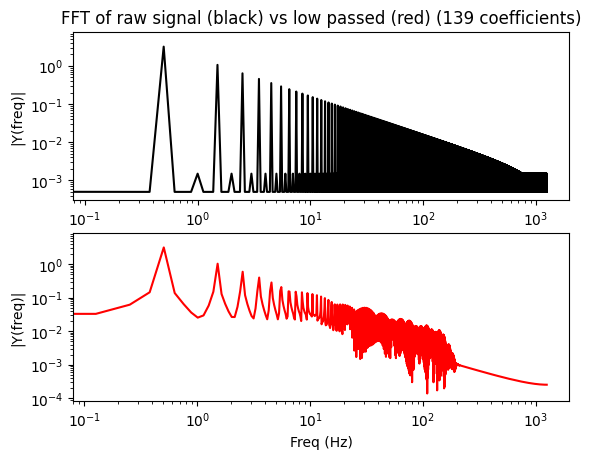

In [798]:
t_fir_c = sigC_df.iloc[len(h_b):][0].values
y_fir_c = sigC_df.iloc[len(h_b):][4].values

Fs_fir_c = Fs_c
n_fir_c = len(y_fir_c)
k_fir_c = np.arange(n_fir_c)
T_fir_c = n_fir_c / Fs_fir_c
frq_fir_c = k_fir_c / T_fir_c
frq_fir_c = frq_fir_c[range(int(n_fir_c/2))]
Y_fir_c = np.fft.fft(y_fir_c)/n_fir_c
Y_fir_c = Y_fir_c[range(int(n_fir_c/2))]

fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.loglog(frq_c, np.abs(Y_c), 'black')
ax2.loglog(frq_fir_c, np.abs(Y_fir_c), 'red')
ax1.set_xlabel('Freq (Hz)')
ax1.set_ylabel('|Y(freq)|')
ax2.set_xlabel('Freq (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax1.set_title(f'FFT of raw signal (black) vs low passed (red) ({len(h_c)} coefficients)')
plt.show()

Signal D

*5 Hz cutoff frequency, 2 Hz bandwidth, Blackman window*

In [809]:
h_d = [
    0.000000000000000000,
    -0.000000178408681892,
    -0.000000612920749554,
    -0.000001012258323255,
    -0.000000956403316485,
    0.000000000000000000,
    0.000002203062742055,
    0.000005776238550962,
    0.000010522253686110,
    0.000015872703346745,
    0.000020902111048003,
    0.000024414546492829,
    0.000025099996605069,
    0.000021745945365175,
    0.000013478643801699,
    0.000000000000000000,
    -0.000018218608032373,
    -0.000039823864058728,
    -0.000062581596358030,
    -0.000083512047363066,
    -0.000099163767364878,
    -0.000106011358900697,
    -0.000100942302941118,
    -0.000081779937819098,
    -0.000047776055534899,
    0.000000000000000000,
    0.000058446531477566,
    0.000122447622254596,
    0.000185161062927062,
    0.000238583035535123,
    0.000274361292736063,
    0.000284791846675165,
    0.000263900515294576,
    0.000208484827926833,
    0.000118978163470847,
    0.000000000000000000,
    -0.000139524329616676,
    -0.000286754054531148,
    -0.000425861206131340,
    -0.000539461712445091,
    -0.000610447575626287,
    -0.000624055122801547,
    -0.000569952919980730,
    -0.000444101215162449,
    -0.000250129109266577,
    0.000000000000000001,
    0.000286209030725181,
    0.000581505203691370,
    0.000854142442871578,
    0.001070619646821489,
    0.001199271880211234,
    0.001214112064487044,
    0.001098509750055624,
    0.000848262689569043,
    0.000473634392469658,
    -0.000000000000000001,
    -0.000533138668762363,
    -0.001074848570657374,
    -0.001567064674353643,
    -0.001950191619869373,
    -0.002169525088665910,
    -0.002181864302308877,
    -0.001961597034060871,
    -0.001505520290551822,
    -0.000835722736406040,
    0.000000000000000002,
    0.000930506999448377,
    0.001866484968382446,
    0.002708159812160881,
    0.003354967350981593,
    0.003716330696643990,
    0.003722486123548943,
    0.003334189697974299,
    0.002550144233117867,
    0.001411120026230892,
    -0.000000000000000002,
    -0.001562656703587806,
    -0.003127498895364592,
    -0.004529206093132568,
    -0.005602277339464676,
    -0.006198412515562179,
    -0.006203821301373091,
    -0.005554652880936182,
    -0.004248773338951399,
    -0.002352337585405777,
    0.000000000000000003,
    0.002611844849674395,
    0.005238748179012586,
    0.007608078733237244,
    0.009443663444008455,
    0.010493195544173195,
    0.010555980203053596,
    0.009508368260268860,
    0.007324253166716014,
    0.004088287385706480,
    -0.000000000000000003,
    -0.004632270041171265,
    -0.009407830245073093,
    -0.013859734661978358,
    -0.017488847863354660,
    -0.019803365815601222,
    -0.020360650050800417,
    -0.018807854151579154,
    -0.014917749921108074,
    -0.008616413714715792,
    0.000000000000000004,
    0.010661332120013137,
    0.022933231374959718,
    0.036240441391246207,
    0.049902130271380379,
    0.063176757848995499,
    0.075313097691462119,
    0.085603431094708415,
    0.093434667964096912,
    0.098333253458952913,
    0.100000184977617326,
    0.098333253458952913,
    0.093434667964096912,
    0.085603431094708415,
    0.075313097691462119,
    0.063176757848995499,
    0.049902130271380386,
    0.036240441391246214,
    0.022933231374959718,
    0.010661332120013137,
    0.000000000000000004,
    -0.008616413714715792,
    -0.014917749921108074,
    -0.018807854151579158,
    -0.020360650050800417,
    -0.019803365815601225,
    -0.017488847863354660,
    -0.013859734661978361,
    -0.009407830245073093,
    -0.004632270041171265,
    -0.000000000000000003,
    0.004088287385706479,
    0.007324253166716014,
    0.009508368260268860,
    0.010555980203053598,
    0.010493195544173200,
    0.009443663444008455,
    0.007608078733237246,
    0.005238748179012587,
    0.002611844849674395,
    0.000000000000000003,
    -0.002352337585405777,
    -0.004248773338951399,
    -0.005554652880936184,
    -0.006203821301373091,
    -0.006198412515562179,
    -0.005602277339464677,
    -0.004529206093132568,
    -0.003127498895364592,
    -0.001562656703587806,
    -0.000000000000000002,
    0.001411120026230893,
    0.002550144233117869,
    0.003334189697974300,
    0.003722486123548945,
    0.003716330696643992,
    0.003354967350981594,
    0.002708159812160881,
    0.001866484968382446,
    0.000930506999448378,
    0.000000000000000002,
    -0.000835722736406040,
    -0.001505520290551821,
    -0.001961597034060871,
    -0.002181864302308878,
    -0.002169525088665912,
    -0.001950191619869374,
    -0.001567064674353644,
    -0.001074848570657374,
    -0.000533138668762363,
    -0.000000000000000001,
    0.000473634392469658,
    0.000848262689569043,
    0.001098509750055624,
    0.001214112064487043,
    0.001199271880211235,
    0.001070619646821490,
    0.000854142442871578,
    0.000581505203691371,
    0.000286209030725181,
    0.000000000000000001,
    -0.000250129109266577,
    -0.000444101215162450,
    -0.000569952919980729,
    -0.000624055122801547,
    -0.000610447575626287,
    -0.000539461712445092,
    -0.000425861206131340,
    -0.000286754054531148,
    -0.000139524329616676,
    0.000000000000000000,
    0.000118978163470847,
    0.000208484827926834,
    0.000263900515294576,
    0.000284791846675165,
    0.000274361292736063,
    0.000238583035535123,
    0.000185161062927062,
    0.000122447622254597,
    0.000058446531477566,
    0.000000000000000000,
    -0.000047776055534899,
    -0.000081779937819098,
    -0.000100942302941118,
    -0.000106011358900697,
    -0.000099163767364878,
    -0.000083512047363066,
    -0.000062581596358031,
    -0.000039823864058728,
    -0.000018218608032373,
    0.000000000000000000,
    0.000013478643801699,
    0.000021745945365175,
    0.000025099996605069,
    0.000024414546492830,
    0.000020902111048004,
    0.000015872703346745,
    0.000010522253686110,
    0.000005776238550962,
    0.000002203062742055,
    0.000000000000000000,
    -0.000000956403316485,
    -0.000001012258323255,
    -0.000000612920749554,
    -0.000000178408681892,
    0.000000000000000000,
]

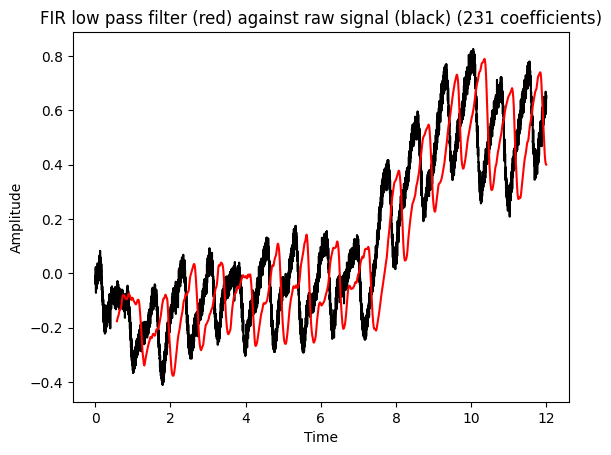

In [810]:
sigD_df[4] = sigD_df[1].rolling(window=len(h_d)).apply(lambda x: np.sum(h_d * x), raw=True)
fir_d = sigD_df[4].values

plt.plot(t_d, y_d, 'black')
plt.plot(t_d, fir_d, 'red')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title(f"FIR low pass filter (red) against raw signal (black) ({len(h_d)} coefficients)")
plt.show()

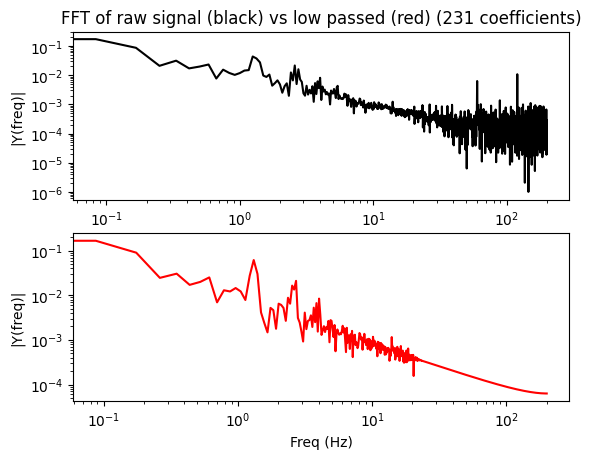

In [811]:
t_fir_d = sigD_df.iloc[len(h_b):][0].values
y_fir_d = sigD_df.iloc[len(h_b):][4].values

Fs_fir_d = Fs_d
n_fir_d = len(y_fir_d)
k_fir_d = np.arange(n_fir_d)
T_fir_d = n_fir_d / Fs_fir_d
frq_fir_d = k_fir_d / T_fir_d
frq_fir_d = frq_fir_d[range(int(n_fir_d/2))]
Y_fir_d = np.fft.fft(y_fir_d)/n_fir_d
Y_fir_d = Y_fir_d[range(int(n_fir_d/2))]

fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.loglog(frq_d, np.abs(Y_d), 'black')
ax2.loglog(frq_fir_d, np.abs(Y_fir_d), 'red')
ax1.set_xlabel('Freq (Hz)')
ax1.set_ylabel('|Y(freq)|')
ax2.set_xlabel('Freq (Hz)')
ax2.set_ylabel('|Y(freq)|')
ax1.set_title(f'FFT of raw signal (black) vs low passed (red) ({len(h_d)} coefficients)')
plt.show()